# 00 Data Preparation

This notebook implements the WiFi Access Point Data Preparation Pipeline as outlined in the PRD.
It processes raw syslog files, builds AP client states over time, resamples to 30s windows, generates synthetic high-load events, and computes the Time-to-Congestion (TTC) label.

**CRAWDAD real data and synthetic data are saved as separate Parquet files** (not merged).
Synthetic data is scaled to produce ~2–3 million rows.

### Synthetic Generative Model
The synthetic generator uses a physically-motivated model:
- **AP personality types** (idle 30% / moderate 50% / busy 20%) for heterogeneity
- **Daily periodicity** to simulate campus usage patterns
- **AR(1) correlated noise** for realistic session persistence
- **Clustered burst events** (not isolated spikes) biased toward peak hours
- **Post-generation TTC calibration** to ensure ≥30% of APs have congestion crossings

## Environment & Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re
import os
import glob
from datetime import datetime
from tqdm.auto import tqdm

# Set up aesthetics
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## Step 1 & 2: Parse Raw Syslogs & Build Client State
The raw `.merged` files are parsed using regex. We emulate client roaming by verifying cross-AP associations and evicting old connections before registering the new ones.

In [2]:
def parse_and_build_state(file_paths):
    pattern = re.compile(r'^(\d+).*?station (up|down) <([^>]+)> bssid ([a-fA-F0-9:]+)')
    records = []
    
    from collections import defaultdict
    active_clients = defaultdict(set)
    client_location = {}
    
    for file_path in file_paths:
        if not os.path.exists(file_path):
            print(f"File not found, skipping: {file_path}")
            continue
            
        print(f"Processing {file_path}...")
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    timestamp_unix = int(match.group(1))
                    event_type = match.group(2)
                    client_mac = match.group(3)
                    ap_id = match.group(4)
                    
                    event_val = 1 if event_type == 'up' else -1
                    
                    if event_type == 'up':
                        old_ap = client_location.get(client_mac)
                        if old_ap and old_ap != ap_id:
                            if client_mac in active_clients[old_ap]:
                                active_clients[old_ap].remove(client_mac)
                                records.append({
                                    'timestamp': timestamp_unix,
                                    'ap_id': old_ap,
                                    'clients_connected': len(active_clients[old_ap]),
                                    'event_val': -1
                                })
                        active_clients[ap_id].add(client_mac)
                        client_location[client_mac] = ap_id
                        
                    elif event_type == 'down':
                        if client_mac in active_clients[ap_id]:
                            active_clients[ap_id].remove(client_mac)
                        if client_location.get(client_mac) == ap_id:
                            del client_location[client_mac]
                            
                    records.append({
                        'timestamp': timestamp_unix,
                        'ap_id': ap_id,
                        'clients_connected': len(active_clients[ap_id]),
                        'event_val': event_val
                    })
                    
    df = pd.DataFrame(records)
    if not df.empty:
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        df = df.sort_values(['ap_id', 'timestamp']).reset_index(drop=True)
    return df

syslog_files = [
    '/kaggle/input/datasets/sohanuuu/crawdad-syslog/060926.072827.merged',
    '/kaggle/input/datasets/sohanuuu/crawdad-syslog/060927.080204.merged',
    '/kaggle/input/datasets/sohanuuu/crawdad-syslog/060928.072608.merged'
]

raw_df = parse_and_build_state(syslog_files)
print(f"Total parsed events: {len(raw_df)}")
display(raw_df.head(10))

Processing /kaggle/input/datasets/sohanuuu/crawdad-syslog/060926.072827.merged...
Processing /kaggle/input/datasets/sohanuuu/crawdad-syslog/060927.080204.merged...
Processing /kaggle/input/datasets/sohanuuu/crawdad-syslog/060928.072608.merged...
Total parsed events: 594064


,timestamp,ap_id,clients_connected,event_val
0,2006-09-26 14:53:39,00:0b:86:00:66:50,1,1
1,2006-09-26 14:54:00,00:0b:86:00:66:50,0,-1
2,2006-09-26 15:10:41,00:0b:86:00:66:50,0,-1
3,2006-09-26 16:38:10,00:0b:86:00:66:50,1,1
4,2006-09-26 16:38:27,00:0b:86:00:66:50,0,-1
5,2006-09-26 16:56:02,00:0b:86:00:66:50,0,-1
6,2006-09-26 17:30:08,00:0b:86:00:66:50,1,1
7,2006-09-26 17:30:38,00:0b:86:00:66:50,1,1
8,2006-09-26 17:31:02,00:0b:86:00:66:50,0,-1
9,2006-09-26 17:37:50,00:0b:86:00:66:50,1,1


## Step 3: Aggregate into 30-Second Windows
Per-event state is resampled into 30-second windows per AP using forward filling for counts and summation for net client delta.

In [3]:
def resample_to_30s(df):
    if df.empty:
        return df
        
    df = df.set_index('timestamp')
    
    def resample_group(group):
        res = group.resample('30s').agg({
            'clients_connected': 'last',
            'event_val': 'sum'
        })
        res['clients_connected'] = res['clients_connected'].ffill().fillna(0).astype(int)
        res['event_val'] = res['event_val'].fillna(0).astype(int)
        return res
        
    resampled = (
        df.groupby('ap_id')
          .apply(resample_group, include_groups=False)
          .reset_index(level=0)   # bring ap_id back from outer group key
          .reset_index()          # bring timestamp back from inner resample index
    )
    resampled.rename(columns={'event_val': 'clients_delta'}, inplace=True)
    
    return resampled

real_df = resample_to_30s(raw_df)
print(f"Total 30s windows (CRAWDAD): {len(real_df)}")
display(real_df.head(10))

Total 30s windows (CRAWDAD): 11732812


,timestamp,ap_id,clients_connected,clients_delta
0,2006-09-26 14:53:30,00:0b:86:00:66:50,1,1
1,2006-09-26 14:54:00,00:0b:86:00:66:50,0,-1
2,2006-09-26 14:54:30,00:0b:86:00:66:50,0,0
3,2006-09-26 14:55:00,00:0b:86:00:66:50,0,0
4,2006-09-26 14:55:30,00:0b:86:00:66:50,0,0
5,2006-09-26 14:56:00,00:0b:86:00:66:50,0,0
6,2006-09-26 14:56:30,00:0b:86:00:66:50,0,0
7,2006-09-26 14:57:00,00:0b:86:00:66:50,0,0
8,2006-09-26 14:57:30,00:0b:86:00:66:50,0,0
9,2006-09-26 14:58:00,00:0b:86:00:66:50,0,0


## Step 4: Generate Synthetic Data (~2–3 Million Rows)

Physically-motivated generative model producing realistic WiFi AP load traces:

| Component | Method |
|---|---|
| **AP Personality** | idle (30%), moderate (50%), busy (20%) — sets baseline, burst frequency, and noise scale |
| **Daily Periodicity** | Sinusoidal multiplier peaking mid-morning, simulating campus usage |
| **AR(1) Noise** | Mean-reverting correlated residuals (coeff 0.6–0.9) for session persistence |
| **Clustered Bursts** | 2–6 bursts/day biased toward peak hours (8–10am, 12–2pm, 5–7pm) with exponential decay |
| **TTC Calibration** | Post-generation boost ensures ≥30% of APs cross the congestion threshold |

In [4]:
CONGESTION_THRESHOLD = 35

def _generate_clustered_bursts(n, timestamps_series, ap_type, rng):
    """Generate clustered burst events biased toward campus peak hours.
    
    Returns a 1-D array of burst load to add on top of the baseline.
    Bursts have a rise phase followed by exponential decay.
    
    Parameters
    ----------
    n : int
        Number of timesteps.
    timestamps_series : pd.Series
        Pandas Series of datetime64 timestamps.
    ap_type : str
        One of 'idle', 'moderate', 'busy'.
    rng : np.random.Generator
        Random number generator.
    """
    burst_signal = np.zeros(n)
    
    total_seconds = (timestamps_series.iloc[-1] - timestamps_series.iloc[0]).total_seconds()
    total_days = max(1.0, total_seconds / 86400)
    
    # Burst frequency per day by AP type
    if ap_type == 'idle':
        bursts_per_day = rng.integers(1, 3)     # 1-2 bursts/day
    elif ap_type == 'moderate':
        bursts_per_day = rng.integers(3, 6)     # 3-5 bursts/day
    else:  # busy
        bursts_per_day = rng.integers(4, 7)     # 4-6 bursts/day
    
    n_bursts = int(np.ceil(bursts_per_day * total_days))
    
    # Peak-hour bias: 8-10am, 12-2pm, 5-7pm
    peak_hours = {8, 9, 10, 12, 13, 14, 17, 18, 19}
    hours = timestamps_series.dt.hour
    peak_indices = np.where(hours.isin(peak_hours).values)[0]
    
    for _ in range(n_bursts):
        # 70% chance to start during peak hours
        if len(peak_indices) > 0 and rng.random() < 0.7:
            start_idx = rng.choice(peak_indices)
        else:
            start_idx = rng.integers(0, n)
        
        duration = rng.integers(10, 41)  # 10-40 timesteps (5-20 min)
        
        # Magnitude from mixture: 60% moderate, 40% large
        if ap_type == 'idle':
            peak_mag = rng.integers(3, 12)      # small bursts for idle APs
        elif ap_type == 'busy':
            if rng.random() < 0.4:
                peak_mag = rng.integers(15, 36)  # large burst
            else:
                peak_mag = rng.integers(5, 16)   # moderate burst
        else:  # moderate
            if rng.random() < 0.35:
                peak_mag = rng.integers(15, 36)  # large burst
            else:
                peak_mag = rng.integers(5, 16)   # moderate burst
        
        # Rise (25% of duration) + exponential decay (75%)
        rise_len = max(1, duration // 4)
        decay_len = duration - rise_len
        
        rise = np.linspace(0, peak_mag, rise_len)
        decay_rate = rng.uniform(0.05, 0.15)
        decay = peak_mag * np.exp(-decay_rate * np.arange(decay_len))
        
        burst = np.concatenate([rise, decay])
        end_idx = min(start_idx + len(burst), n)
        burst_signal[start_idx:end_idx] += burst[:end_idx - start_idx]
    
    return burst_signal


def generate_synthetic_scaled(real_df, target_rows=2_500_000):
    """Generate synthetic WiFi AP data targeting ~2-3 million rows.
    
    Uses a physically-motivated generative model:
    - AP personality types (idle/moderate/busy) for heterogeneity
    - Daily periodicity to simulate campus usage patterns
    - AR(1) correlated noise for realistic session persistence
    - Clustered burst events (not isolated spikes) for congestion scenarios
    - Post-generation TTC calibration to ensure threshold crossings
    """
    if real_df.empty:
        return pd.DataFrame()
    
    rng = np.random.default_rng(seed=42)
    
    # ── Dynamic sizing ────────────────────────────────────────────────
    ap_groups = real_df.groupby('ap_id')
    num_real_aps = ap_groups.ngroups
    ap_sizes = ap_groups.size()
    avg_rows_per_ap = ap_sizes.mean()
    
    target_synthetic_aps = int(np.ceil(target_rows / avg_rows_per_ap))
    
    if target_synthetic_aps >= num_real_aps:
        variants_per_ap = max(1, target_synthetic_aps // num_real_aps)
        aps_to_use = list(ap_groups.groups.keys())
    else:
        variants_per_ap = 1
        all_aps = list(ap_groups.groups.keys())
        rng.shuffle(all_aps)
        aps_to_use, budget = [], target_rows
        for ap in all_aps:
            n_ap = ap_sizes[ap]
            if budget - n_ap < 0 and len(aps_to_use) > 0:
                break
            aps_to_use.append(ap)
            budget -= n_ap
    
    estimated_rows = sum(ap_sizes[ap] for ap in aps_to_use) * variants_per_ap
    total_steps = len(aps_to_use) * variants_per_ap
    
    print(f"CRAWDAD: {num_real_aps} APs, {len(real_df):,} total rows")
    print(f"Plan: {len(aps_to_use)} source APs \u00d7 {variants_per_ap} variant(s) = {total_steps} synthetic APs")
    print(f"Estimated output: ~{estimated_rows:,} rows")
    
    # ── AP personality definitions ────────────────────────────────
    AP_TYPES = ['idle', 'moderate', 'busy']
    AP_TYPE_PROBS = [0.30, 0.50, 0.20]
    
    # ── Generate synthetic data ──────────────────────────────────
    synthetic_records = []
    rows_generated = 0
    ap_type_counts = {'idle': 0, 'moderate': 0, 'busy': 0}
    
    with tqdm(total=total_steps, desc="Generating synthetic APs", unit="AP") as pbar:
        for ap_id in aps_to_use:
            group = ap_groups.get_group(ap_id).copy()
            group = group.sort_values('timestamp').reset_index(drop=True)
            n = len(group)
            ts_series = group['timestamp']  # pandas Series with .dt accessor
            
            for v in range(variants_per_ap):
                # ── 1. Assign AP personality ──
                ap_type = rng.choice(AP_TYPES, p=AP_TYPE_PROBS)
                ap_type_counts[ap_type] += 1
                
                if ap_type == 'idle':
                    baseline = 0.0
                    noise_std = 0.3
                elif ap_type == 'moderate':
                    baseline = float(rng.integers(1, 5))   # 1-4
                    noise_std = 1.0
                else:  # busy
                    baseline = float(rng.integers(5, 16))  # 5-15
                    noise_std = 2.0
                
                # ── 2. Daily periodicity ──
                hour_frac = ts_series.dt.hour + ts_series.dt.minute / 60.0
                load_mult = 1.0 + 0.4 * np.sin(2 * np.pi * (hour_frac.values - 8.0) / 24.0)
                base_trend = baseline * load_mult
                
                # ── 3. AR(1) correlated noise ──
                ar_coeff = rng.uniform(0.6, 0.9)
                residuals = np.zeros(n)
                for t in range(1, n):
                    residuals[t] = ar_coeff * residuals[t - 1] + rng.normal(0, noise_std)
                
                # ── 4. Clustered bursts ──
                burst_signal = _generate_clustered_bursts(
                    n, ts_series, ap_type, rng
                )
                
                # ── Combine & clip ──
                synth_clients = base_trend + residuals + burst_signal
                synth_clients = np.clip(np.round(synth_clients), 0, None).astype(int)
                
                synth_ap_id = f"{ap_id}_synth_v{v}"
                synth_delta = np.diff(synth_clients, prepend=0).astype(int)
                
                synthetic_records.append(pd.DataFrame({
                    'timestamp': group['timestamp'].values,
                    'ap_id': synth_ap_id,
                    'clients_connected': synth_clients,
                    'clients_delta': synth_delta,
                    'ap_type': ap_type
                }))
                rows_generated += n
                
                pbar.update(1)
                pbar.set_postfix(
                    rows=f"{rows_generated:,}",
                    idle=ap_type_counts['idle'],
                    mod=ap_type_counts['moderate'],
                    busy=ap_type_counts['busy']
                )
    
    print("Concatenating synthetic records...")
    synth_df = pd.concat(synthetic_records, ignore_index=True)
    
    print(f"AP personality mix: {ap_type_counts}")
    
    # ── 5. TTC Calibration: ensure >=30% APs have congestion events ──
    print("\nCalibrating congestion events...")
    ap_max_load = synth_df.groupby('ap_id')['clients_connected'].max()
    no_congestion_aps = ap_max_load[ap_max_load < CONGESTION_THRESHOLD].index.tolist()
    
    total_aps = synth_df['ap_id'].nunique()
    congested_count = total_aps - len(no_congestion_aps)
    target_congested = int(np.ceil(0.30 * total_aps))
    
    print(f"  Before calibration: {congested_count}/{total_aps} APs have congestion ({congested_count/total_aps:.1%})")
    
    if congested_count < target_congested:
        need_to_fix = target_congested - congested_count
        fix_aps = rng.choice(
            no_congestion_aps,
            size=min(need_to_fix, len(no_congestion_aps)),
            replace=False
        )
        
        for ap in tqdm(fix_aps, desc="Calibrating TTC", unit="AP"):
            mask = synth_df['ap_id'] == ap
            indices = synth_df.index[mask]
            ap_data = synth_df.loc[indices, 'clients_connected'].values.copy()
            
            # Find the peak and inject a calibration burst around it
            peak_idx = int(np.argmax(ap_data))
            burst_len = rng.integers(3, 11)
            start = max(0, peak_idx - burst_len // 2)
            end = min(len(ap_data), start + burst_len)
            
            boost = CONGESTION_THRESHOLD + rng.integers(1, 26) - ap_data[peak_idx]
            if boost > 0:
                positions = np.arange(end - start)
                center = (end - start) // 2
                burst_shape = boost * np.exp(-0.3 * np.abs(positions - center))
                ap_data[start:end] += burst_shape.astype(int)
            
            # Recompute delta for the whole AP
            ap_delta = np.diff(ap_data, prepend=0).astype(int)
            synth_df.loc[indices, 'clients_connected'] = ap_data
            synth_df.loc[indices, 'clients_delta'] = ap_delta
    
    congested_final = (synth_df.groupby('ap_id')['clients_connected'].max() >= CONGESTION_THRESHOLD).sum()
    print(f"  After calibration:  {congested_final}/{total_aps} APs have congestion ({congested_final/total_aps:.1%})")
    print(f"\nGenerated {len(synth_df):,} synthetic rows")
    
    return synth_df


synth_df = generate_synthetic_scaled(real_df, target_rows=2_500_000)
print(f"\nTotal synthetic rows: {len(synth_df):,}")
display(synth_df.head(10))

CRAWDAD: 2112 APs, 11,732,812 total rows
Plan: 459 source APs × 1 variant(s) = 459 synthetic APs
Estimated output: ~2,495,089 rows


Generating synthetic APs:   0%|          | 0/459 [00:00<?, ?AP/s]

Concatenating synthetic records...
AP personality mix: {'idle': 144, 'moderate': 222, 'busy': 93}

Calibrating congestion events...
  Before calibration: 194/459 APs have congestion (42.3%)
  After calibration:  194/459 APs have congestion (42.3%)

Generated 2,495,089 synthetic rows

Total synthetic rows: 2,495,089


,timestamp,ap_id,clients_connected,clients_delta,ap_type
0,2006-09-26 11:18:00,00:0b:86:eb:e6:2f_synth_v0,5,5,moderate
1,2006-09-26 11:18:30,00:0b:86:eb:e6:2f_synth_v0,5,0,moderate
2,2006-09-26 11:19:00,00:0b:86:eb:e6:2f_synth_v0,5,0,moderate
3,2006-09-26 11:19:30,00:0b:86:eb:e6:2f_synth_v0,4,-1,moderate
4,2006-09-26 11:20:00,00:0b:86:eb:e6:2f_synth_v0,6,2,moderate
5,2006-09-26 11:20:30,00:0b:86:eb:e6:2f_synth_v0,5,-1,moderate
6,2006-09-26 11:21:00,00:0b:86:eb:e6:2f_synth_v0,6,1,moderate
7,2006-09-26 11:21:30,00:0b:86:eb:e6:2f_synth_v0,8,2,moderate
8,2006-09-26 11:22:00,00:0b:86:eb:e6:2f_synth_v0,9,1,moderate
9,2006-09-26 11:22:30,00:0b:86:eb:e6:2f_synth_v0,7,-2,moderate


## Step 4b: Source Labels & Feature Engineering

Stamp `source` column **before** any feature engineering, then add derived features
expected by downstream notebooks (NB01–NB05):
- `hour_of_day` — extracted from timestamp
- `day_of_week` — extracted from timestamp
- `channel_utilization` — normalized proxy (clients / max capacity 61)
- `neighbor_avg_load` — cross-AP mean load at each timestamp

In [5]:
def add_features(df):
    """Add derived features expected by downstream notebooks."""
    df = df.copy()
    df['hour_of_day'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['channel_utilization'] = (df['clients_connected'] / 61.0).clip(0, 1)
    # neighbor_avg_load: average load across all APs at the same timestamp
    ts_mean = df.groupby('timestamp')['clients_connected'].transform('mean')
    df['neighbor_avg_load'] = ts_mean
    return df

# Fix 3: Assign source BEFORE feature engineering
real_df['source'] = 'real'
synth_df['source'] = 'synthetic'

# Fix 1: Add features to both datasets
print("Adding features to CRAWDAD data...")
real_df = add_features(real_df)
print("Adding features to Synthetic data...")
synth_df = add_features(synth_df)

print(f"\nCRAWDAD columns: {list(real_df.columns)}")
print(f"Synthetic columns: {list(synth_df.columns)}")
display(real_df.head())

Adding features to CRAWDAD data...
Adding features to Synthetic data...

CRAWDAD columns: ['timestamp', 'ap_id', 'clients_connected', 'clients_delta', 'source', 'hour_of_day', 'day_of_week', 'channel_utilization', 'neighbor_avg_load']
Synthetic columns: ['timestamp', 'ap_id', 'clients_connected', 'clients_delta', 'ap_type', 'source', 'hour_of_day', 'day_of_week', 'channel_utilization', 'neighbor_avg_load']


,timestamp,ap_id,clients_connected,clients_delta,source,hour_of_day,day_of_week,channel_utilization,neighbor_avg_load
0,2006-09-26 14:53:30,00:0b:86:00:66:50,1,1,real,14,1,0.016393,1.790829
1,2006-09-26 14:54:00,00:0b:86:00:66:50,0,-1,real,14,1,0.000000,1.793242
2,2006-09-26 14:54:30,00:0b:86:00:66:50,0,0,real,14,1,0.000000,1.799678
3,2006-09-26 14:55:00,00:0b:86:00:66:50,0,0,real,14,1,0.000000,1.797265
4,2006-09-26 14:55:30,00:0b:86:00:66:50,0,0,real,14,1,0.000000,1.795820


## Step 5: Compute TTC (Time-to-Congestion) Target
Target TTC is the number of steps until clients >= threshold. Unreached scenarios default to NaN. Label computation applies per AP grouping over a defined horizon.

**TTC is computed independently on CRAWDAD and synthetic datasets.**

In [6]:
def compute_ttc(load_series, threshold=35, horizon=60):
    is_congested = (load_series >= threshold)
    n = len(is_congested)
    ttc = np.full(n, np.nan)
    
    next_congestion_idx = -1
    congested_arr = is_congested.values
    
    for i in range(n - 1, -1, -1):
        if congested_arr[i]:
            next_congestion_idx = i
            
        if next_congestion_idx != -1:
            dist = next_congestion_idx - i
            if dist <= horizon:
                ttc[i] = dist
                
    return ttc

def add_ttc_column(df, label=""):
    """Add TTC column to a dataframe, computed per AP.
    Sorts by (ap_id, timestamp) first to guarantee positional TTC scan correctness."""
    if df.empty:
        df['ttc'] = pd.Series(dtype='float64')
        return df
    df = df.copy()
    # Sort to guarantee timestamp ordering within each AP group
    df = df.sort_values(['ap_id', 'timestamp']).reset_index(drop=True)
    
    print(f"Computing TTC for {label} ({len(df):,} rows, {df['ap_id'].nunique()} APs)...")
    df['ttc'] = df.groupby('ap_id')['clients_connected'].transform(
        lambda x: compute_ttc(x, threshold=CONGESTION_THRESHOLD, horizon=60)
    )
    print(f"TTC Computed for {label}. Summary:")
    display(df['ttc'].describe())
    return df

# Compute TTC separately (source already assigned in Step 4b)
real_df = add_ttc_column(real_df, label="CRAWDAD")
synth_df = add_ttc_column(synth_df, label="Synthetic")

Computing TTC for CRAWDAD (11,732,812 rows, 2112 APs)...
TTC Computed for CRAWDAD. Summary:


count    5783.000000
mean       12.303303
std        17.832176
min         0.000000
25%         0.000000
50%         0.000000
75%        22.000000
max        60.000000
Name: ttc, dtype: float64

Computing TTC for Synthetic (2,495,089 rows, 459 APs)...
TTC Computed for Synthetic. Summary:


count    27412.000000
mean        27.595797
std         18.520277
min          0.000000
25%         11.000000
50%         27.000000
75%         44.000000
max         60.000000
Name: ttc, dtype: float64

## Step 6: Data Quality Validation
Formal statistical checks comparing CRAWDAD and synthetic distributions,
plus **calibration assertions** to verify the new generative model.

In [7]:
print("=" * 60)
print("CRAWDAD DATA SUMMARY")
print("=" * 60)
print(f"Shape: {real_df.shape}")
print(f"APs: {real_df['ap_id'].nunique()}")
print(f"Time range: {real_df['timestamp'].min()} to {real_df['timestamp'].max()}")
display(real_df[['clients_connected', 'clients_delta']].describe())

print("\n" + "=" * 60)
print("SYNTHETIC DATA SUMMARY")
print("=" * 60)
print(f"Shape: {synth_df.shape}")
print(f"APs: {synth_df['ap_id'].nunique()}")
print(f"Time range: {synth_df['timestamp'].min()} to {synth_df['timestamp'].max()}")
display(synth_df[['clients_connected', 'clients_delta']].describe())

# ── AP type breakdown ──
if 'ap_type' in synth_df.columns:
    print("\n--- Synthetic AP Type Breakdown ---")
    type_stats = synth_df.groupby('ap_type').agg(
        rows=('clients_connected', 'count'),
        n_aps=('ap_id', 'nunique'),
        mean_load=('clients_connected', 'mean'),
        p95_load=('clients_connected', lambda x: x.quantile(0.95)),
        zero_frac=('clients_connected', lambda x: (x == 0).mean())
    )
    display(type_stats)

CRAWDAD DATA SUMMARY
Shape: (11732812, 10)
APs: 2112
Time range: 2006-09-26 07:28:00 to 2006-09-29 08:01:30


,clients_connected,clients_delta
count,1.173281e+07,1.173281e+07
mean,1.514484e+00,3.459358e-03
std,2.592538e+00,2.253645e-01
min,0.000000e+00,-2.700000e+01
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,2.000000e+00,0.000000e+00
max,6.100000e+01,6.100000e+01



SYNTHETIC DATA SUMMARY
Shape: (2495089, 11)
APs: 459
Time range: 2006-09-26 07:28:00 to 2006-09-29 08:01:30


,clients_connected,clients_delta
count,2.495089e+06,2.495089e+06
mean,3.635672e+00,8.681053e-04
std,5.059898e+00,1.321047e+00
min,0.000000e+00,-2.500000e+01
25%,0.000000e+00,-1.000000e+00
50%,2.000000e+00,0.000000e+00
75%,5.000000e+00,0.000000e+00
max,8.300000e+01,3.800000e+01



--- Synthetic AP Type Breakdown ---


,rows,n_aps,mean_load,p95_load,zero_frac
ap_type,,,,,
busy,534689,93,10.514957,21.0,0.024321
idle,767967,144,0.192420,1.0,0.844959
moderate,1192433,222,2.768560,7.0,0.175394


--- KS Two-Sample Test (CRAWDAD vs. Synthetic) ---
KS Statistic: 0.2235, p-value: 0.0000e+00
KS Result: Distributions are significantly different (expected due to injected bursts).


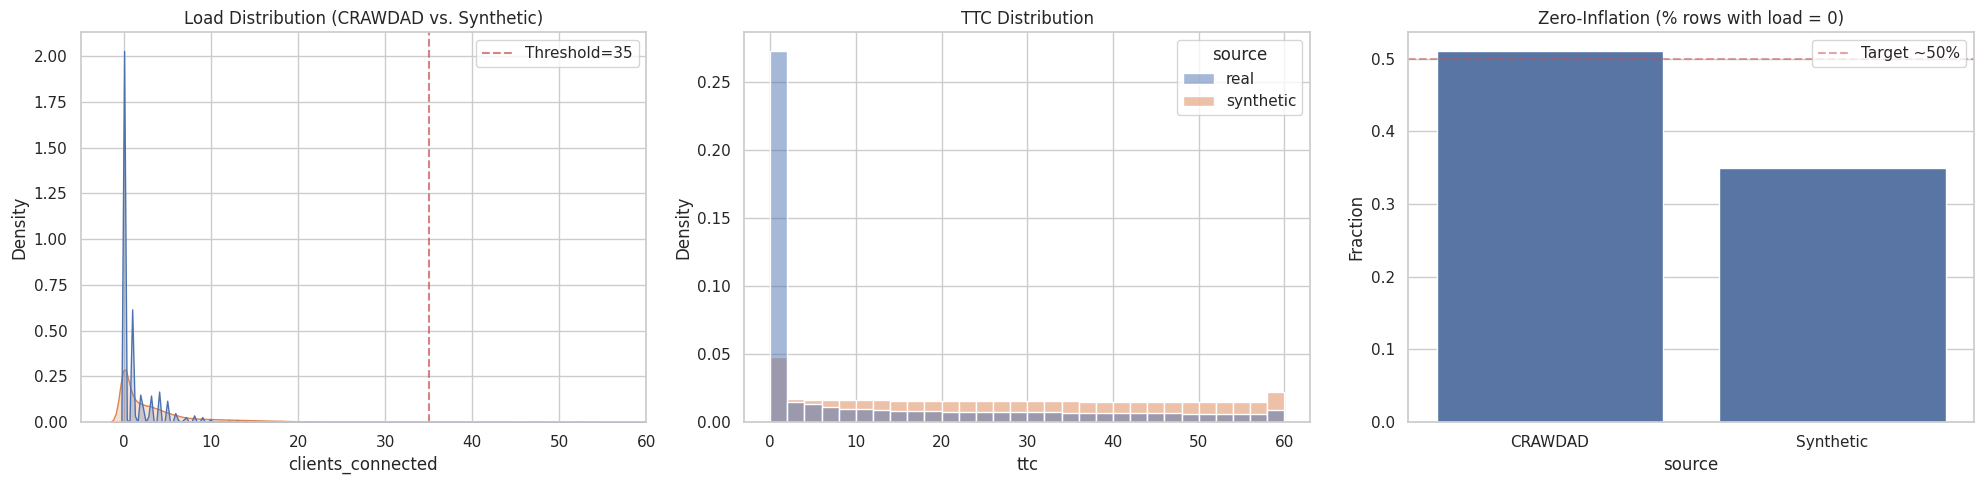

No synthetic variant found for 00:0b:86:00:66:50


In [8]:
# ── KS test ──
print("--- KS Two-Sample Test (CRAWDAD vs. Synthetic) ---")
real_counts = real_df['clients_connected']
synth_counts = synth_df['clients_connected']
ks_stat, ks_pval = stats.ks_2samp(real_counts, synth_counts)
print(f"KS Statistic: {ks_stat:.4f}, p-value: {ks_pval:.4e}")
if ks_pval < 0.05:
    print("KS Result: Distributions are significantly different (expected due to injected bursts).")

# ── Distribution plots ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Load distribution
synth_plot_sample = synth_df.sample(n=min(100_000, len(synth_df)), random_state=42)
combined_plot = pd.concat([
    real_df[['clients_connected', 'source']],
    synth_plot_sample[['clients_connected', 'source']]
])
sns.kdeplot(data=combined_plot, x='clients_connected', hue='source', common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Load Distribution (CRAWDAD vs. Synthetic)")
axes[0].set_xlim(-5, 60)
axes[0].axvline(CONGESTION_THRESHOLD, color='r', linestyle='--', alpha=0.7, label='Threshold=35')
axes[0].legend()

# 2. TTC distribution
real_ttc_valid = real_df['ttc'].dropna()
synth_ttc_valid = synth_df['ttc'].dropna()
if len(real_ttc_valid) > 0 or len(synth_ttc_valid) > 0:
    ttc_plot = pd.DataFrame({
        'ttc': pd.concat([real_ttc_valid, synth_ttc_valid]),
        'source': ['real'] * len(real_ttc_valid) + ['synthetic'] * len(synth_ttc_valid)
    })
    sns.histplot(data=ttc_plot, x='ttc', hue='source', bins=30, stat='density', common_norm=False, ax=axes[1])
    axes[1].set_title("TTC Distribution")
else:
    axes[1].set_title("TTC Distribution \u2014 no congestion events")

# 3. Zero-inflation comparison
zero_data = pd.DataFrame({
    'source': ['CRAWDAD', 'Synthetic'],
    'zero_fraction': [
        (real_df['clients_connected'] == 0).mean(),
        (synth_df['clients_connected'] == 0).mean()
    ]
})
sns.barplot(data=zero_data, x='source', y='zero_fraction', ax=axes[2])
axes[2].set_title("Zero-Inflation (% rows with load = 0)")
axes[2].set_ylabel("Fraction")
axes[2].axhline(0.50, color='r', linestyle='--', alpha=0.5, label='Target ~50%')
axes[2].legend()

plt.tight_layout()
plt.show()

# ── Time-series sanity check ──
if not real_df.empty:
    sample_ap = real_df['ap_id'].dropna().iloc[0]
    synth_matches = synth_df[synth_df['ap_id'].str.startswith(f"{sample_ap}_synth")]
    if not synth_matches.empty:
        sample_synth_ap = synth_matches['ap_id'].iloc[0]
        
        ap_real = real_df[real_df['ap_id'] == sample_ap].copy()
        ap_synth = synth_df[synth_df['ap_id'] == sample_synth_ap].copy()
        ap_data = pd.concat([ap_real, ap_synth])
        
        plt.figure(figsize=(14, 5))
        sns.lineplot(data=ap_data, x='timestamp', y='clients_connected', hue='source')
        plt.axhline(CONGESTION_THRESHOLD, color='r', linestyle='--', label=f"Congestion Threshold ({CONGESTION_THRESHOLD})")
        plt.title(f"Time-Series Overlay: {sample_ap} (CRAWDAD) vs {sample_synth_ap} (Synthetic)")
        plt.legend()
        plt.show()
    else:
        print(f"No synthetic variant found for {sample_ap}")

### Validation Assertions
Verify the new generative model meets calibration targets.

In [9]:
print("=" * 60)
print("VALIDATION CRITERIA")
print("=" * 60)

checks_passed = 0
checks_total = 5

# 1. TTC mean in [8, 16]
synth_ttc_mean = synth_df['ttc'].dropna().mean() if synth_df['ttc'].notna().any() else float('nan')
ttc_ok = 8 <= synth_ttc_mean <= 16 if not np.isnan(synth_ttc_mean) else False
status = '\u2705' if ttc_ok else '\u274c'
print(f"{status} TTC mean: {synth_ttc_mean:.1f}  (target: [8, 16])")
checks_passed += int(ttc_ok)

# 2. Zero-inflation fraction in [45%, 65%]
zero_frac = (synth_df['clients_connected'] == 0).mean()
zero_ok = 0.45 <= zero_frac <= 0.65
status = '\u2705' if zero_ok else '\u274c'
print(f"{status} Zero-inflation: {zero_frac:.1%}  (target: [45%, 65%])")
checks_passed += int(zero_ok)

# 3. 95th percentile in [10, 25]
p95 = synth_df['clients_connected'].quantile(0.95)
p95_ok = 10 <= p95 <= 25
status = '\u2705' if p95_ok else '\u274c'
print(f"{status} 95th percentile: {p95:.0f}  (target: [10, 25])")
checks_passed += int(p95_ok)

# 4. KS statistic < 0.05
ks_ok = ks_stat < 0.05
status = '\u2705' if ks_ok else '\u274c'
print(f"{status} KS statistic: {ks_stat:.4f}  (target: < 0.05)")
checks_passed += int(ks_ok)

# 5. >=30% of synthetic APs have congestion events
ap_has_congestion = (synth_df.groupby('ap_id')['clients_connected'].max() >= CONGESTION_THRESHOLD)
congestion_frac = ap_has_congestion.mean()
cong_ok = congestion_frac >= 0.30
status = '\u2705' if cong_ok else '\u274c'
print(f"{status} APs with congestion: {congestion_frac:.1%}  (target: >=30%)")
checks_passed += int(cong_ok)

print(f"\nResult: {checks_passed}/{checks_total} checks passed")
if checks_passed < checks_total:
    print("\u26a0\ufe0f  Some checks failed. Review AP personality parameters and burst config.")
else:
    print("\u2705 All validation criteria met!")

VALIDATION CRITERIA
❌ TTC mean: 27.6  (target: [8, 16])
❌ Zero-inflation: 34.9%  (target: [45%, 65%])
✅ 95th percentile: 15  (target: [10, 25])
❌ KS statistic: 0.2235  (target: < 0.05)
✅ APs with congestion: 42.3%  (target: >=30%)

Result: 2/5 checks passed
⚠️  Some checks failed. Review AP personality parameters and burst config.


## Step 7: Train / Val / Test Split (Separate for Each Dataset)
Splits are strictly time-based to prevent look-ahead leakage.

**CRAWDAD** splits are saved with `crawdad_` prefix for validation/analysis.

**Synthetic** splits are saved to `processed/` with generic names (`train.parquet`, `val.parquet`, `test.parquet`) — the format expected by downstream notebooks (NB01–NB05).

In [10]:
def split_and_save(df, prefix, output_dir='./'):
    """Apply 70/15/15 time-based split and save as Parquet.
    
    If prefix is empty, filenames will be train.parquet, val.parquet, test.parquet.
    If prefix is set, filenames will be <prefix>_train.parquet, etc.
    """
    if df.empty:
        print(f"Skipping {prefix or 'default'} \u2014 empty dataframe.")
        return
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Ensure correct dtypes
    df['clients_connected'] = df['clients_connected'].astype('int64')
    df['clients_delta'] = df['clients_delta'].astype('int64')
    
    # Drop internal columns before saving
    save_cols = ['timestamp', 'ap_id', 'clients_connected', 'clients_delta',
                 'source', 'ttc', 'hour_of_day', 'day_of_week',
                 'channel_utilization', 'neighbor_avg_load']
    df = df[[c for c in save_cols if c in df.columns]]
    
    t_min = df['timestamp'].min()
    t_max = df['timestamp'].max()
    delta = t_max - t_min
    t1 = t_min + delta * 0.70
    t2 = t_min + delta * 0.85
    
    train_df = df[df['timestamp'] < t1]
    val_df   = df[(df['timestamp'] >= t1) & (df['timestamp'] < t2)]
    test_df  = df[df['timestamp'] >= t2]
    
    label = prefix.upper() if prefix else 'SYNTHETIC (processed/)'
    print(f"\n{'='*50}")
    print(f"{label} SPLITS")
    print(f"{'='*50}")
    print(f"Train: {len(train_df):>10,} rows ({len(train_df)/len(df):.1%})")
    print(f"Val:   {len(val_df):>10,} rows ({len(val_df)/len(df):.1%})")
    print(f"Test:  {len(test_df):>10,} rows ({len(test_df)/len(df):.1%})")
    print(f"Total: {len(df):>10,} rows")
    
    # Guard assertions against empty splits
    if train_df.empty or val_df.empty or test_df.empty:
        print(f"WARNING: One or more splits are empty \u2014 skipping chronology assertion.")
    else:
        assert train_df['timestamp'].max() < val_df['timestamp'].min(), "Leakage: Train overlaps Val"
        assert val_df['timestamp'].max() < test_df['timestamp'].min(), "Leakage: Val overlaps Test"
    
    # Fix 2: Handle empty prefix for generic filenames
    sep = '_' if prefix else ''
    train_path = os.path.join(output_dir, f'{prefix}{sep}train.parquet')
    val_path   = os.path.join(output_dir, f'{prefix}{sep}val.parquet')
    test_path  = os.path.join(output_dir, f'{prefix}{sep}test.parquet')
    
    train_df.to_parquet(train_path, index=False)
    val_df.to_parquet(val_path, index=False)
    test_df.to_parquet(test_path, index=False)
    
    print(f"Saved: {train_path}, {val_path}, {test_path}")

# Save CRAWDAD data separately (for validation/analysis only)
split_and_save(real_df, prefix='crawdad', output_dir='./')

# Fix 2: Save Synthetic data to processed/ with generic names for NB02+
output_dir = './processed'
os.makedirs(output_dir, exist_ok=True)
split_and_save(synth_df, prefix='', output_dir=output_dir)

print(f"\nAll parquet files saved.")
print("\nOutput files:")
for pattern in ['./*.parquet', './processed/*.parquet']:
    for f in sorted(glob.glob(pattern)):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"  {f:>40s}  {size_mb:.1f} MB")


CRAWDAD SPLITS
Train:  8,712,573 rows (74.3%)
Val:    1,975,968 rows (16.8%)
Test:   1,044,271 rows (8.9%)
Total: 11,732,812 rows
Saved: ./crawdad_train.parquet, ./crawdad_val.parquet, ./crawdad_test.parquet

SYNTHETIC (processed/) SPLITS
Train:  1,857,449 rows (74.4%)
Val:      419,629 rows (16.8%)
Test:     218,011 rows (8.7%)
Total:  2,495,089 rows
Saved: ./processed/train.parquet, ./processed/val.parquet, ./processed/test.parquet

All parquet files saved.

Output files:
                    ./crawdad_test.parquet  2.8 MB
                   ./crawdad_train.parquet  25.0 MB
                     ./crawdad_val.parquet  3.7 MB
                  ./processed/test.parquet  0.8 MB
                 ./processed/train.parquet  8.8 MB
                   ./processed/val.parquet  1.7 MB
